**Aim:** make Slice-Seq details for Fig. 4 in the manuscript

**Author:** Yike Xie

**Date Updated:** 30 Mar 2026

In [1]:
# Load libraries
import os
import re
import sys
sys.path.append("..")
import utils
get_ipython().run_line_magic('matplotlib', 'inline')

import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42

from scipy.stats import spearmanr
from adjustText import adjust_text

import warnings
warnings.filterwarnings("ignore")

In [2]:
fig_folder = '../../figures/manuscript_figures/figure5-6/'
data_folder = '../../data/'
res_folder = '../../tables/spatial/'

os.makedirs(fig_folder, exist_ok=True)
os.makedirs(data_folder, exist_ok=True)
os.makedirs(res_folder, exist_ok=True)

# Data Loading

## basic information

In [3]:
metadata = pd.read_excel('../../figures/manuscript_figures/tables/Table1_human_donor_information.xlsx', 
                       index_col=0, sheet_name='Pancreas')

tech_cols = ["snRNA-Seq", "Immunostaining", "Spatial transcriptomics", "Calcium imaging", "Slice-Seq"]
tech_mask = metadata[tech_cols].astype(str).apply(lambda s: s.str.lower().str.strip().eq("yes"))

metadata["Method"] = tech_mask.apply(
    lambda row: ", ".join([col for col, ok in row.items() if ok]),
    axis=1
)

In [4]:
### only keep protein coding genes
gene_type = pd.read_csv(
    '/home/yike/resources/Human_Sapiens_gene_type.csv', 
    sep=',', index_col='gene_type'
)

protein_coding_genes = gene_type.loc['protein_coding']['gene_name'].tolist()

## spatial data

In [5]:
if False:
    # this dataset includes the Local Moran's I results
    adata = sc.read_h5ad('../data/YK_raw_spatial_islet_extra_islet_c2l_annot_hq.h5ad')
    adata.obs['group'] = metadata.loc[adata.obs['sample'].str.split('-').str[0]]['group'].to_list()

In [6]:
# this is the data after neighborhood and subtype annotation
adata = sc.read_h5ad('../../data/YK_raw_spatial_ct_cst_c2l_annot_hq_neighbor_clustering_20260107.h5ad')
adata.obs['group'] = metadata.loc[adata.obs['sample'].str.split('-').str[0]]['group'].to_list()

In [7]:
# add default colors for each cell type and cell subtype

def set_adata_colors(
    adata,
    col,
    *,
    color_map=None,          # dict: category -> color (hex or named)
):
    """
    Ensure adata.obs[col] is categorical and set adata.uns[f"{col}_colors"]
    with NO None values (Scanpy requires valid colors for all categories).
    """
    if color_map is None:
        color_map = {}

    # --- ensure categorical
    s = adata.obs[col]
    cats = list(adata.obs[col].cat.categories)

    # --- big fallback palette (repeatable)
    base = []
    for cm in ["tab20", "tab20b", "tab20c"]:
        base.extend([mpl.colors.to_hex(c) for c in mpl.cm.get_cmap(cm).colors])
    # repeat if needed
    fallback = (base * ((len(cats) // len(base)) + 1))[:len(cats)]

    # --- start from fallback then override with user map
    colors = fallback[:]
    for i, c in enumerate(cats):
        if c in color_map and color_map[c] is not None:
            colors[i] = mpl.colors.to_hex(mpl.colors.to_rgb(color_map[c]))

    # --- final safety: replace any accidental 'None' or invalid strings
    colors = ["#BFBFBF" if (x is None or str(x).lower() == "none") else x for x in colors]

    adata.uns[f"{col}_colors"] = colors
    return cats, colors

annot_colors = {
    # 'Acinar': (0.80, 0.80, 0.80), # lightgrey # (0.90, 0.45, 0.40), # soft coral red

    'Acinar': (1.0, 0.831, 0.624),
    'Stellate': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), # orange
    'Ductal': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), # blue
    'Endothelial': (0.5019607843137255, 0.0, 0.5019607843137255), # gray
    'Islet_endocrine': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), # green
    'Extra_islet_endocrine': (0.5647058823529412, 0.9333333333333333, 0.5647058823529412), # lightgreen
    
    'Immune': (0.984313725490196, 0.6862745098039216, 0.8941176470588236), # pink
    'Schwann': (0.5019607843137255, 0.5019607843137255, 0.5019607843137255), # black

     'Basal_acinar': (0.7372549019607844, 0.5607843137254902, 0.5607843137254902),
     'Idling_acinar': (0.7372549019607844, 0.5607843137254902, 0.5607843137254902),
     'Intermediate_acinar': (0.9411764705882353, 0.5019607843137255, 0.5019607843137255),
     'Signaling_acinar': (0.5019607843137255, 0.0, 0.0),

     'Activated_stellates': (1.0, 0.8941176470588236, 0.7686274509803922),
     'Quiescent_stellates': (1.0, 0.5490196078431373, 0.0),

     'Basal_ductal': (0.6901960784313725, 0.7686274509803922, 0.8705882352941177),
     'Inflam_ductal_1': (0.0, 0.7490196078431373, 1.0), 
     'Inflam_ductal_2': (0.2549019607843137, 0.4117647058823529, 0.8823529411764706),
     'MUC5B+_ductal': (0.0, 0.0, 0.5019607843137255),

     'Endothelial': (0.5019607843137255, 0.0, 0.5019607843137255), 
     'Arterial_ECs': (0.8666666666666667, 0.6274509803921569, 0.8666666666666667),
     'Venous_ECs': (0.9333333333333333, 0.5098039215686274, 0.9333333333333333),
     'Capillary_ECs': (0.5019607843137255, 0.0, 0.5019607843137255),
     'Lymphatic_ECs': (0.29411764705882354, 0.0, 0.5098039215686274),

     'Islet_α': (0.5607843137254902, 0.7372549019607844, 0.5607843137254902), # medium soft green
     'Islet_β': (0.0, 0.5019607843137255, 0.0), # dark green
     'Islet_γ': (0.5647058823529412, 0.9333333333333333, 0.5647058823529412), # very light green
     'Islet_δ': (0.3333333333333333, 0.4196078431372549, 0.1843137254901961), # olive green
     'Islet_α_β': (0.2000, 0.6500, 0.3500), 
    
     'Extra_islet_β': (0.0000, 0.6500, 0.5500),   # teal-green
     'Extra_islet_non-β': (0.4000, 0.8000, 0.6500),  # soft mint-green

     'Macrophages': (0.8470588235294118, 0.7490196078431373, 0.8470588235294118),
     'Plasmablasts':  (1.0, 0.7529411764705882, 0.796078431372549),
     'T_cells': (0.8588235294117647, 0.4392156862745098, 0.5764705882352941),
     'Mast_cells': (1.0, 0.0, 1.0),

     'Schwann': (0.5019607843137255, 0.5019607843137255, 0.5019607843137255)
}

# reorder annotated cell types and subtyoes
adata.obs['annot_celltype'] = adata.obs['annot_celltype'].cat.reorder_categories(
    ['Islet_endocrine', 'Extra_islet_endocrine', 
     'Acinar', 'Ductal', 'Endothelial', 'Stellate', 
     'Immune', 'Schwann']
)
adata.obs['annot_cellsubtype'] = adata.obs['annot_cellsubtype'].cat.reorder_categories(
    ['Islet_α', 'Islet_β', 'Islet_α_β', 'Islet_γ', 'Islet_δ', 'Islet_Low quality',
     'Extra_islet_β', 'Extra_islet_non-β', 
     'Acinar', 
     'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal', 
     'Arterial_ECs', 'Venous_ECs','Capillary_ECs', 'Lymphatic_ECs', 
     'Macrophages', 'Plasmablasts', 'T_cells', 'Mast_cells', 
     'Quiescent_stellates', 'Activated_stellates',  
     'Schwann']
)

# add build in colors of each cell type and cell subtype
set_adata_colors(adata, "annot_celltype", color_map=annot_colors)
set_adata_colors(adata, "annot_cellsubtype", color_map=annot_colors)

(['Islet_α',
  'Islet_β',
  'Islet_α_β',
  'Islet_γ',
  'Islet_δ',
  'Islet_Low quality',
  'Extra_islet_β',
  'Extra_islet_non-β',
  'Acinar',
  'Basal_ductal',
  'Inflam_ductal_1',
  'Inflam_ductal_2',
  'MUC5B+_ductal',
  'Arterial_ECs',
  'Venous_ECs',
  'Capillary_ECs',
  'Lymphatic_ECs',
  'Macrophages',
  'Plasmablasts',
  'T_cells',
  'Mast_cells',
  'Quiescent_stellates',
  'Activated_stellates',
  'Schwann'],
 ['#8fbc8f',
  '#008000',
  '#33a659',
  '#90ee90',
  '#556b2f',
  '#98df8a',
  '#00a68c',
  '#66cca6',
  '#ffd49f',
  '#b0c4de',
  '#00bfff',
  '#4169e1',
  '#000080',
  '#dda0dd',
  '#ee82ee',
  '#800080',
  '#4b0082',
  '#d8bfd8',
  '#ffc0cb',
  '#db7093',
  '#ff00ff',
  '#ff8c00',
  '#ffe4c4',
  '#808080'])

In [8]:
adata_raw = adata.copy()

# all_mac as the log2 normalized version
sc.pp.filter_genes(adata, min_cells=10)
sc.pp.normalize_total(adata, target_sum=1e4, inplace=True)  # CP10K scale
sc.pp.log1p(adata, base=2) # log2 transform

- 'sample' column is the sample column
- 'barcode' (also index/obs_names) are the spatial barcodes for each spot on the curio slide
- 'x'/'y' are the spatial coords

**NOTE:** Some samples have really low quality. V32 is also a replica of V31 - this one I have removed.

## load preliminary data

In [9]:
# load islet features
islet_features = pd.read_csv(
    '../../tables/spatial/islet_analysis/spatial_islet_features.tsv', 
    sep='\t', index_col=1)

# distance between cell types 
dist_df = pd.read_csv(
    '../../tables/spatial/islet_analysis/spatial_islet_sharpen_distance.tsv', 
    sep='\t', index_col=0)

# load the neighbor information of endocrine spots
ct_neighbors = pd.read_csv(
    '../../tables/spatial/islet_analysis/ct_by_neighbors/ct_neighbor_combinations_with_exocrine.tsv', 
    sep='\t', index_col=0)

## functions

In [10]:
from scipy.stats import rankdata, t
from sklearn.feature_selection import mutual_info_regression
from statsmodels.stats.multitest import multipletests

def spearman_corr(X, y, gene_exps):
    # Optional: handle NaNs (drop any sample with NaN in BMI or any gene)
    # If NaNs are sparse, you might prefer per-gene masking instead of global drop.
    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    y = y[mask]
    X = X[mask, :]
    n, p = X.shape

    # 1) Rank-transform (column-wise for X, vector for y)
    y_rank = rankdata(y, method='average')              # (n,)
    X_rank = np.apply_along_axis(rankdata, 0, X)        # (n, p)

    # 2) Z-score ranks (so Pearson on ranks = Spearman)
    y_z = (y_rank - y_rank.mean()) / y_rank.std(ddof=1)            # (n,)
    X_z = (X_rank - X_rank.mean(axis=0)) / X_rank.std(axis=0, ddof=1)  # (n, p)

    # 3) Correlations in one shot: r = (y_z^T X_z) / (n-1)
    rho = (y_z @ X_z) / (n - 1)                         # (p,)

    # 4) p-values via t distribution with df = n-2
    #    t = r * sqrt((n-2)/(1-r^2))
    den = np.clip(1 - rho**2, 1e-15, None) # ensures the denominator never goes below 1e-15
    tvals = rho * np.sqrt((n - 2) / den) # test statistic
    pvals = 2 * t.sf(np.abs(tvals), df=n - 2) # two-sided p-values, 
    # t.sf(x, df) survival function = P(T>x) for a Student’s t-distribution with df degrees of freedom

    # 5) Assemble results + FDR
    sp_corr = pd.DataFrame({'rho': rho, 'pval': pvals}, index=gene_exps.index)
    sp_corr = sp_corr.sort_values('rho', ascending=False)
    
    return sp_corr

def pearson_corr(X, y, gene_exps):
    # 0) Handle NaNs: drop any sample with NaN in y or any gene (global mask)
    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    y = y[mask]
    X = X[mask, :]
    n, p = X.shape

    # 1) Z-score raw data (Pearson uses centered, scaled values)
    y_z = (y - y.mean()) / y.std(ddof=1)                 # (n,)
    X_mean = X.mean(axis=0)                               # (p,)
    X_std  = X.std(axis=0, ddof=1)                        # (p,)
    # avoid divide-by-zero for constant genes
    X_std[X_std == 0] = np.nan
    X_z = (X - X_mean) / X_std                            # (n, p)

    # 2) Correlations in one shot: r = (y_z^T X_z) / (n-1)
    rho = (y_z @ X_z) / (n - 1)                           # (p,)
    # genes with zero variance -> nan; you can set to 0 if you prefer:
    # rho = np.nan_to_num(rho, nan=0.0)

    # 3) Two-sided p-values via t distribution with df = n-2
    #    t = r * sqrt((n-2)/(1-r^2))
    den = np.clip(1 - rho**2, 1e-15, None)
    tvals = rho * np.sqrt((n - 2) / den)
    pvals = 2 * t.sf(np.abs(tvals), df=n - 2)

    # 4) Assemble results (+ optional FDR)
    pearson_corr = pd.DataFrame({'r': rho, 'pval': pvals}, index=gene_exps.index)
    pearson_corr = pearson_corr.sort_values('r', ascending=False)
    
    return pearson_corr

In [11]:
import gseapy as gp

def get_pth_res(genes, gene_sets, fig_FDR, n_entities):
    
    all_results = []
    for gs in gene_sets:
        enr = gp.enrichr(
            gene_list=genes,
            gene_sets=gs,
            organism='Human',
            cutoff=False)
        res = enr.res2d.copy()
        all_results.append(res)

    df = pd.concat(all_results, ignore_index=True)

    df['Pathway identifier'] = df['Term'].str.split('(').str[-1].str[:-1]
    df['#Entities found'] = df['Overlap'].str.split('/').str[0].astype('int')
    df['#Entities total'] = df['Overlap'].str.split('/').str[1].astype('int')

    df_strict = df[
            (df['Adjusted P-value'] < fig_FDR) # < 0.1
            & (df['#Entities found'].astype('int') > n_entities)
        ]

    return df_strict

In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from scipy.spatial import ConvexHull
from matplotlib.path import Path
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colors import to_rgb, to_hex

def midpoint_hex(h1, h2):
    rgb1, rgb2 = np.array(to_rgb(h1)), np.array(to_rgb(h2))
    return to_hex((rgb1+rgb2)/2)

def _hex_to_rgb01(h): 
    h = h.lstrip("#"); return np.array([int(h[i:i+2],16) for i in (0,2,4)])/255

def _srgb_to_linear(c): 
    a=0.055; return np.where(c<=0.04045, c/12.92, ((c+a)/(1+a))**2.4)
def _linear_to_srgb(c): 
    a=0.055; return np.where(c<=0.0031308, 12.92*c, (1+a)*(np.clip(c,0,1)**(1/2.4))-a)

M1 = np.array([[0.41222147,0.53633254,0.05144599],
               [0.21190350,0.68069955,0.10739696],
               [0.08830246,0.28171884,0.62997870]])
M2 = np.array([[0.21045426,0.79361779,-0.00407205],
               [1.97799850,-2.42859221,0.45059371],
               [0.02590404,0.78277177,-0.80867576]])
M1i, M2i = np.linalg.inv(M1), np.linalg.inv(M2)

def _hex_to_oklab(h):
    lin = _srgb_to_linear(_hex_to_rgb01(h)); lms = M1 @ lin; lms_c = np.cbrt(lms); return M2 @ lms_c
def _oklab_to_hex(Lab):
    lms_c = M2i @ Lab; lms = lms_c**3; lin = M1i @ lms; srgb = _linear_to_srgb(lin); 
    srgb = np.clip(srgb,0,1); return to_hex(srgb)

def blend_oklab(h1, h2, t=0.65):  # t=0.65 → 65% α (pink), 35% β (orange)
    return _oklab_to_hex((1-t)*_hex_to_oklab(h2) + t*_hex_to_oklab(h1))

def plot_islet_knn_regions(
    adata,
    islet,
    *,
    ax=None,                         # you can pass an axes; if None, a new one is created
    label_col="dominant",
    base_colors=None,
    crop=None,                       # (x_min, x_max, y_min, y_max)
    grid_steps=600,
    k=10, eps=None, min_samples=1,
    region_alpha=0.25, spot_size=6,
    invert_x=True
):
    """
    - Regions (contourf): transparent fill using per-class colors (from A.uns[f"{label_col}_colors"])
    - Spots: solid per-class colors (via sc.pl.spatial using the same palette)
    """

    # --- subset and pull data
    A = adata[adata.obs["islet"].isin(islet)].copy()
    X = A.obsm["spatial"]  # shape (n_spots, 2)

    if crop is None:
        x_min, x_max = X[:, 0].min() - 20, X[:, 0].max() + 20
        y_min, y_max = X[:, 1].min() - 20, X[:, 1].max() + 20
    else:
        x_min, x_max, y_min, y_max = crop

    # --- grid for region coloring
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_steps),
        np.linspace(y_min, y_max, grid_steps)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # --- DBSCAN islet detection (cluster spots into islets)
    if eps is None:
        n_neighbors = min(5, len(X))
        d, _ = NearestNeighbors(n_neighbors=n_neighbors).fit(X).kneighbors(X)
        eps = 2.5 * np.median(d[:, 1])
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
    islets = [i for i in np.unique(labels) if i != -1]

    # ----- fixed global palette (order matters)
    class_order = ["α", "β", "γ", "δ", "α_β"]

    if base_colors is None:
        base_colors = {
            "α":   "#FF0000",  # red
            "β":   "#00FF00",  # green
            "γ":   "#17BECF",  # teal (this one was already correct)
            "δ":   "#FFFF00",  # yellow
            "α_β": "#FFA500",  # orange

            # "α":   "#E377C2",  # pink
            # "β":   "#FF7F0E",  # orange
            # "γ":   "#17BECF",  # teal
            # "δ":   "#1F77B4",  # blue
            # "α_β": "#FFD700",  # yellow
        }

    # Which classes are present in this subset (preserve your desired class_order)
    present = pd.Index(A.obs[label_col].dropna().unique())
    cats = [c for c in class_order if c in present]

    # Make the column categorical with exactly these categories
    A.obs[label_col] = pd.Categorical(A.obs[label_col], categories=cats, ordered=False)

    # Build palette aligned to category order
    fallback = "#999999"
    palette = [base_colors.get(c, fallback) for c in cats]
    A.uns[f"{label_col}_colors"] = palette  # Scanpy will use this automatically

    # Colormap/normalization for contourf regions (index-based classes 0..len(cats)-1)
    cmap = ListedColormap(palette)
    levels = np.arange(-0.5, len(cats) + 0.5, 1.0)
    norm = BoundaryNorm(levels, cmap.N)

    # Global LUT: class label -> integer index in cats
    lut = {c: i for i, c in enumerate(cats)}

    # --- axes
    created_ax = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 6))
        created_ax = True

    contour_artists = []

    # Pre-fetch labels as a numpy array (no string casting; keep NaN as NaN)
    y_all = A.obs[label_col].to_numpy()

    for isl in islets:
        idx = np.where(labels == isl)[0]
        if idx.size < 5:
            continue

        Xi = X[idx]
        yi = y_all[idx]

        # Drop NaNs for local classifier
        valid_mask = ~ pd.isna(yi)
        Xi = Xi[valid_mask]
        yi = yi[valid_mask]
        if Xi.shape[0] < 5 or len(np.unique(yi)) < 2:
            continue

        # Islet polygon (convex hull) and mask points inside
        hull = ConvexHull(Xi) if Xi.shape[0] >= 3 else None
        poly = Xi[hull.vertices] if hull is not None else Xi
        inside = Path(poly).contains_points(grid)
        ii = np.where(inside)[0]
        if ii.size == 0:
            continue

        # Local KNN classifier in this islet
        le = LabelEncoder()
        yi_enc = le.fit_transform(yi)  # local class indices

        knn = KNeighborsClassifier(n_neighbors=k, weights="distance")
        knn.fit(Xi, yi_enc)

        # Predict on grid points inside the islet polygon
        Zi_local = knn.predict(grid[ii])  # local indices
        # Map local class labels -> global palette indices
        local2global = {j: lut.get(lbl, -1) for j, lbl in enumerate(le.classes_)}
        Zi = np.vectorize(local2global.get)(Zi_local)

        # Fold back into full grid for contourf
        Z = np.full(xx.size, np.nan)
        Z[ii] = Zi
        Z = Z.reshape(xx.shape)

        # Transparent region fill using our colormap
        ca = ax.contourf(
            xx, yy, Z,
            levels=np.arange(-0.5, len(cats) + 0.5, 1.0),
            cmap=cmap, norm=norm, alpha=region_alpha
        )
        contour_artists.append(ca)

    # ----- overlay spots in solid colors (same palette via A.uns)
    sc.pl.spatial(
        A,
        color=[label_col],
        spot_size=spot_size,
        show=False,
        ax=ax,
        crop_coord=(x_min, x_max, y_min, y_max),
        alpha=0.6,
    )

    if invert_x:
        ax.invert_xaxis()

    artists = {"contours": contour_artists}
    return (ax, artists) if not created_ax else (fig, ax, artists)

# QC metrics (Slice-seq vs others)

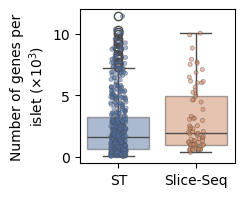

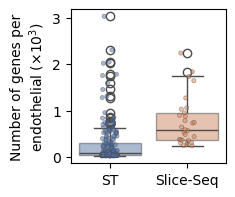

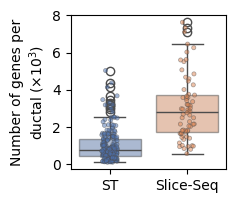

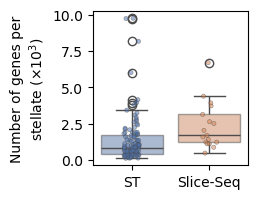

In [ ]:
neighbor_annots = [
    'islet_kept',
    'endothelial_niche_kept',
    'ductal_niche_kept',
    'stellate_niche_kept', 
]

slice_seq_samples = ['U6-slice', 'U11', 'V34', 'V35', 'V36', 'C19']
plot_order = ['ST', 'Slice-Seq']
plot_by = 'Method'
colors = sns.color_palette("deep", 2)
palette = dict(zip(plot_order, colors))

for neighbor_annot in neighbor_annots:
    adata_tmp = adata_raw[adata_raw.obs[neighbor_annot].notna()].copy()

    adata_tmp.obs['Method'] = 'ST'
    adata_tmp.obs.loc[
        adata_tmp.obs['sample'].isin(slice_seq_samples), 'Method'
        ] = 'Slice-Seq'
    
    # get the number of genes detected in each neighbor
    neighbor_type = neighbor_annot.split('_')[0].lower()
    neighbors = adata_tmp.obs[neighbor_annot].values
    unique_neighbors = np.unique(neighbors)

    results = []
    for ngb in unique_neighbors:
        idx = np.where(neighbors == ngb)[0]
        sub = adata_tmp.X[idx]
        n_genes = (sub.sum(axis=0) > 0).A1.sum()
        i = adata_tmp.obs.loc[
            adata_tmp.obs[neighbor_annot] == ngb, plot_by
            ].iloc[0]
        results.append((ngb, i, n_genes))

    genes_per_neighbor = pd.DataFrame(
        results,
        columns=[neighbor_annot, plot_by, f'n_genes_{neighbor_type}']
    )
    genes_per_neighbor[f'n_genes_{neighbor_type} (K)'] = (
        genes_per_neighbor[f'n_genes_{neighbor_type}'] / 1e3)

    genes_per_neighbor['group'] = metadata.loc[
        genes_per_neighbor[neighbor_annot].str.split('_').str[0].str.split('-').str[0]
        ]['group'].tolist()
    genes_per_neighbor['sample'] = genes_per_neighbor[neighbor_annot].str.split('_').str[0].str.split('-').str[0].tolist()

    # plotting
    fig, ax = plt.subplots(figsize=(2, 2))

    sns.boxplot(
        data=genes_per_neighbor,
        x=plot_by,
        y=f'n_genes_{neighbor_type} (K)',
        ax=ax,
        order=plot_order,
        palette=palette
    )
    for patch in ax.patches:
        patch.set_alpha(0.5)

    sns.stripplot(
        data=genes_per_neighbor,
        x=plot_by,
        y=f'n_genes_{neighbor_type} (K)',
        # hue='sample',
        # palette='Set2',
        palette=palette,
        size=3,
        edgecolor=None,
        linewidth=0.5,
        ax=ax,
        order=plot_order,
        alpha=0.5
    )
    ax.legend().remove()
    ax.set_xlabel(None)
    ax.set_ylabel('Number of genes per\n' + f'{neighbor_type} (×10$^3$)')
    # ax.set_title(f'Number of {neighbor_type} genes by {plot_by.lower()}')

    plt.show()

    fig.savefig(
        os.path.join(
            '../../figures/manuscript_figures/figure4/',
            f'number_of_genes_per_{neighbor_type}_by_{plot_by}_2.png'
        ), 
        dpi=300, bbox_inches='tight'
    )

    fig.savefig(
        os.path.join(
            '../../figures/manuscript_figures/figure4/',
            f'number_of_genes_per_{neighbor_type}_by_{plot_by}_2.pdf'
        ), 
        dpi=300, bbox_inches='tight'
    )

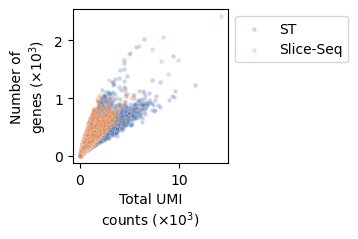

In [ ]:
# scatterplot per cell type

slice_seq_samples = ['U6-slice', 'U11', 'V34', 'V35', 'V36', 'C19']
# Define colors explicitly (optional but recommended)
plot_order = ['ST', 'Slice-Seq']
colors = sns.color_palette("deep", 2)
palette = dict(zip(plot_order, colors))
plot_by = 'Method'

adata_tmp = adata_raw.copy()
adata_tmp.obs['Method'] = 'ST'
adata_tmp.obs.loc[
    adata_tmp.obs['sample'].isin(slice_seq_samples), 'Method'
    ] = 'Slice-Seq'
adata_tmp.obs['n_genes_by_counts (K)'] = (adata_tmp.obs['n_genes_by_counts'] / 1e3)
adata_tmp.obs['total_counts (K)'] = (adata_tmp.obs['total_counts'] / 1e3)

# plotting
fig, ax = plt.subplots(figsize=(2, 2))

# Plot Slide-Seq first (background)
sns.scatterplot(
    data=adata_tmp.obs[adata_tmp.obs[plot_by] == 'ST'],
    x='total_counts (K)',
    y='n_genes_by_counts (K)',
    ax=ax,
    color=palette['ST'],
    s=10,
    alpha=0.3,
    label='ST'
)

# Plot Slice-Seq second (on top)
sns.scatterplot(
    data=adata_tmp.obs[adata_tmp.obs[plot_by] == 'Slice-Seq'],
    x='total_counts (K)',
    y='n_genes_by_counts (K)',
    ax=ax,
    color=palette['Slice-Seq'],
    s=10,
    alpha=0.3,
    label='Slice-Seq'
)

ax.set_xlabel('Total UMI\ncounts (×10$^3$)')
ax.set_ylabel('Number of\ngenes (×10$^3$)')

ax.legend(
    # title=plot_by.replace('_', ' ').capitalize(), 
    bbox_to_anchor=(1, 1), 
    loc='upper left', 
    frameon=True)

ax.grid(False)

plt.show()

fig.savefig(
    os.path.join(
        '../../figures/manuscript_figures/figure4/',
        f'spatial_scatterplot_ngenes_nUMIs_by_{plot_by}_5.png'
    ), 
    dpi=300, bbox_inches='tight'
)
fig.savefig(
    os.path.join(
        '../../figures/manuscript_figures/figure4/',
        f'spatial_scatterplot_ngenes_nUMIs_by_{plot_by}_5.pdf'
    ), 
    dpi=300, bbox_inches='tight'
)

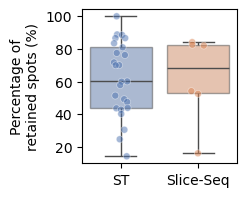

In [ ]:
slice_seq_samples = ['U6-slice', 'U11', 'V34', 'V35', 'V36', 'C19']
plot_order = ['ST', 'Slice-Seq']
plot_by = 'Method'
colors = sns.color_palette("deep", 2)
palette = dict(zip(plot_order, colors))

# adata_tmp = adata_raw.copy()
# adata_tmp.obs['Method'] = 'ST'
# adata_tmp.obs.loc[
#     adata_tmp.obs['sample'].isin(slice_seq_samples), 'Method'
#     ] = 'Slice-Seq'
# adata_tmp.obs['n_genes_by_counts (K)'] = (adata_tmp.obs['n_genes_by_counts'] / 1e3)
# adata_tmp.obs['total_counts (K)'] = (adata_tmp.obs['total_counts'] / 1e3)

pct = adata_tmp.obs['sample'].value_counts() * 100 / adata_tmp.obs['sample'].value_counts().max()
region_pct_df = pct.to_frame(name='pct')

region_pct_df['Method'] = 'ST'
region_pct_df.loc[
    region_pct_df.index.isin(slice_seq_samples), 'Method'
    ] = 'Slice-Seq'

fig, ax = plt.subplots(figsize=(2, 2))
sns.boxplot(
    data=region_pct_df,
    x='Method',
    y='pct',
    ax=ax,
    order=plot_order,
    palette=palette,
)
for patch in ax.patches:
    patch.set_alpha(0.5)

sns.stripplot(
    data=region_pct_df,
    x='Method',
    y='pct',
    ax=ax,
    order=plot_order,
    size=5,
    edgecolor='w',
    linewidth=0.5,
    palette=palette,
    alpha=0.5
)

ax.set_xlabel(None)
ax.set_ylabel('Percentage of\nretained spots (%)')

plt.show()

fig.savefig(
    os.path.join(
        '../../figures/manuscript_figures/figure4/',
        f'percentage_of_retained_spots_by_{plot_by}.png'
    ), 
    dpi=300, bbox_inches='tight'
)   

fig.savefig(
    os.path.join(
        '../../figures/manuscript_figures/figure4/',
        f'percentage_of_retained_spots_by_{plot_by}.pdf'
    ), 
    dpi=300, bbox_inches='tight'
) 

# Ca2+ activate cells %

In [6]:
pseudo_bulk_cpm = {}
pseudo_bulk_log2cpm = {}

for ct in ['all', 'α', 'β']:
    tmp_df = pd.read_csv(
        os.path.join(fig_folder, f'slice-seq_qc/Slice-Seq_pseudo_bulk_cpm_per_islet_{ct}_cells.csv'),
        sep=',', index_col=0
    )
    pseudo_bulk_cpm[ct] = tmp_df
    pseudo_bulk_log2cpm[ct] = np.log2(tmp_df + 1)

In [7]:
islet_rename_dic = {
        'U6': 'U6-slice_0', 
        'V34': 'V34_0', 
        'V35': 'V35_0', 
        'V36_1': 'V36_9', 
        'V36_2': 'V36_10', 
        'V36_3': 'V36_11'}

activity_df = pd.read_excel(
    '../../figures/manuscript_figures/references/calcium_imaging/total_activity_over_all_cells_per_islet.xlsx',
    index_col=0)
activity_df = activity_df.rename(index=islet_rename_dic)

alpha_act_df = pd.read_excel(
    '../../figures/manuscript_figures/references/calcium_imaging/alpha_activity_over_all_alpha_cells_per_islet.xlsx',
    index_col=0)
alpha_act_df = alpha_act_df.rename(index=islet_rename_dic)

beta_act_df = pd.read_excel(
    '../../figures/manuscript_figures/references/calcium_imaging/beta_activity_over_all_beta_cells_per_islet_updated.xlsx',
    index_col=0)
beta_act_df = beta_act_df.rename(index=islet_rename_dic)

alpha_act_ot_df = pd.read_excel(
    '../../figures/manuscript_figures/references/calcium_imaging/alpha_activity_over_all_cells_per_islet.xlsx',
    index_col=0)
alpha_act_ot_df = alpha_act_ot_df.rename(index=islet_rename_dic)

beta_act_ot_df = pd.read_excel(
    '../../figures/manuscript_figures/references/calcium_imaging/beta_activity_over_all_cells_per_islet.xlsx',
    index_col=0)
beta_act_ot_df = beta_act_ot_df.rename(index=islet_rename_dic)

In [9]:
count_df_dic = {
    '%_active_cells_over_all_cells': activity_df,
    '%_active_α_cells_over_all_α_cells': alpha_act_df,
    '%_active_β_cells_over_all_β_cells': beta_act_df,
    '%_active_α_cells_over_all_cells': alpha_act_ot_df,
    '%_active_β_cells_over_all_cells': beta_act_ot_df
}

islet_order = [
    'U6-slice_0', 'V34_0', 'V35_0',
    'V36_9', 'V36_10', 'V36_11'
]

anno_df = pd.DataFrame(columns=islet_order)
anno_df.loc[r'size [log$_1$$_0$(µm$^2$)]'] = np.log10(islet_features.loc[islet_order]['area'])
anno_df.loc['% α cells'] = 100 * islet_features.loc[islet_order]['alpha_frac']
anno_df.loc['% β cells'] = 100 * islet_features.loc[islet_order]['beta_frac']

analyze_groups = {
    '1 mM': [
        '%_active_α_cells_over_all_α_cells', 
        '%_active_α_cells_over_all_cells', 
        ], 
    '10 mM': [
        '%_active_β_cells_over_all_β_cells',
        '%_active_β_cells_over_all_cells'], 
}

for modality, count_methods in analyze_groups.items():
    for count_method in count_methods:
        ct = count_method.split('_')[2]
        base_ct = count_method.split('_')[-2]
        cat = f'Active {ct} (% {base_ct}, {modality})'
        
        # f'{count_method.replace('_', ' ')} at glu {modality}'
        anno_df.loc[cat] = count_df_dic[count_method].loc[islet_order][modality]

In [11]:
genes_to_plot_dic = {
    'genes\nident': [
        'INS', 'IAPP', 'NKX6-1', 
        # 'PDX1', 'MAFA', 
        # 'GCG', 'TTR', 
        'MAFB','ISL1', 
        # 'ARX', 'SST', 'HHEX', 'PPY', 'RBP4'
        ],
    # 'glucose\nmetabolism': [
    #     'HADH', 'G6PC2', 'GCK', 'SLC2A1', 'SLC2A2', 
    #     'PC', 'GLUD1', ],
    'K\nchannel': [
        # 'ABCC5', 'ABCC9',
        'ABCC8', 
        'KCNK16', 
        # 'KCNJ8', 
        'KCNJ11', #'KCNB1', 
        # 'KCNMA1', 'KCNQ1',
        ],
    # 'Na\nchannel': [
    #     'SCN3A', 'SCN3B', 'SCNN1A'], # 'SCN2A', 
    'Ca\nchannel': [
        'CALM2', 'CACNA1A', 
        # 'CACNB2', 'CACNA1C', 'CACNA1D', # 'CACNA1H', 
        'CACNA2D1', 
        ],
    'coupling': ['GJD2'], #'GJA1', 
    'exocytosis': [
        'CHGA', 'CHGB', 'SLC30A8', 
        # 'SNAP25', 'STX1A', 'STX4',
        # 'VAMP2', 'RAB3B', 'RAB27A', 'RAB26',
        'SYT7', 
        # 'SYT16', 
        ],
    'incretin\nsignaling': [
        'GLP1R', 'GIPR', 'FFAR1', 
        # 'GPR119', 'ADCY5'
        ],
    # 'disallowed\ncore': ['LDHA', 'HK1'], # 'SLC16A1', 
    'ligand-receptor\npairs': [
        # 'CHRM3', 'SSTR2', 
        'GCGR', 
        # 'PCSK1', 'SLC18A2', 
        ],
}

genes_to_plot = []
for cat, genes in genes_to_plot_dic.items():
    genes_to_plot += genes


In [ ]:
label_col = "islet_label_sharpen"

adata_islet = adata[
    adata.obs["islets_in_out"].eq('in') &
    adata.obs["islet"].notna() &
    adata.obs[label_col].notna() &
    (~ adata.obs[label_col].isin(["Low quality", "α_β"]))
].copy()

In [491]:
islets = ['U6-slice_0', 'V35_0', 'V36_9', 'V36_10', 'V36_11', 'V34_0']
adata_ss_islet = adata_islet[adata_islet.obs['islet'].isin(islets)].copy()

adata_ss_islet_show = adata_ss_islet[:, genes_to_plot].copy()
sc.pp.scale(adata_ss_islet_show, zero_center=False)

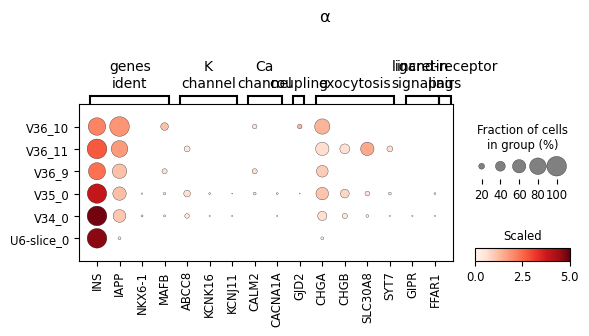

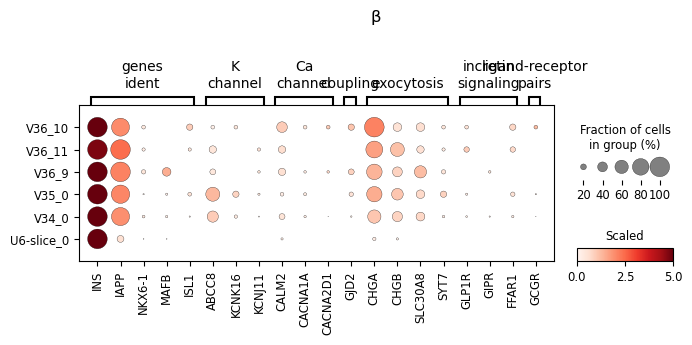

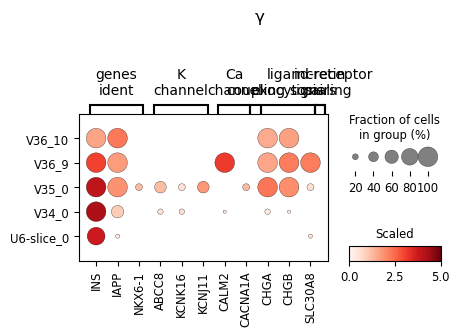

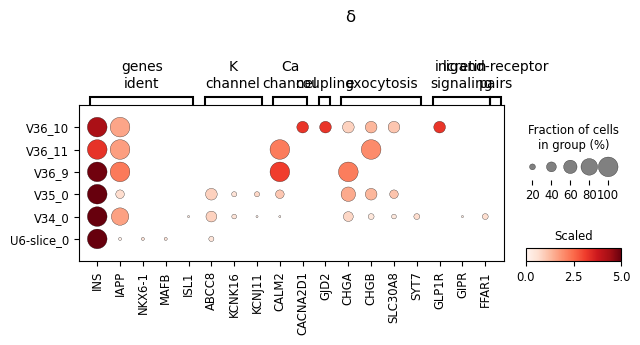

In [502]:
islet_order = ['V36_10', 'V36_11', 'V36_9', 'V35_0', 'V34_0', 'U6-slice_0']

for ct in ['Islet_α', 'Islet_β', 'Islet_γ', 'Islet_δ']:

    adata_tmp = adata_ss_islet[adata_ss_islet.obs['annot_cellsubtype'] == ct].copy()
    # remove genes not expressed in this celltype
    mean_exp = np.array(adata_tmp[:, genes_to_plot].X.mean(axis=0)).ravel()
    genes_to_skip = {
        gene
        for gene, mean in zip(genes_to_plot, mean_exp)
        if mean == 0}
    genes_to_plot_dic_tmp = {
        cat: [g for g in genes if g not in genes_to_skip]
        for cat, genes in genes_to_plot_dic.items()}

    # plot
    genes_to_plot_tmp = []
    for cat, genes in genes_to_plot_dic_tmp.items():
        genes_to_plot_tmp += genes
    adata_tmp_show = adata_tmp[:, genes_to_plot_tmp].copy()
    sc.pp.scale(adata_tmp_show, zero_center=False)

    fig, ax = plt.subplots(figsize=[len(genes_to_plot_tmp) / 3 + 1, 3])
    axs = sc.pl.dotplot(adata_tmp_show, 
                var_names=genes_to_plot_dic_tmp,
                groupby="islet",
                categories_order = [i for i in islet_order if i in adata_tmp_show.obs['islet'].unique()],
                color_map='Reds', 
                var_group_rotation=0,
                colorbar_title = 'Scaled', vmax=5,
                use_raw=False, show=False,
                ax=ax,)
    ax.set_title(ct.split('_')[1])
    
    fig.savefig(
        os.path.join(
            fig_folder, 
            f'slice-seq_qc/scaled_dotplot_per_islet_insterested_genes_{ct.split('_')[1]}.png'), 
        dpi=300, bbox_inches='tight')
    fig.savefig(
        os.path.join(
            fig_folder, 
            f'slice-seq_qc/scaled_dotplot_per_islet_insterested_genes_{ct.split('_')[1]}.pdf'), 
        dpi=300, bbox_inches='tight')

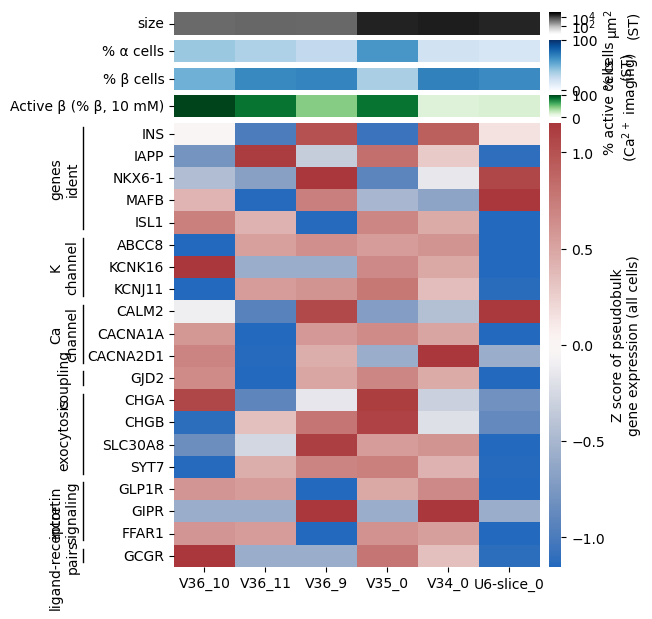

In [13]:
from matplotlib.gridspec import GridSpec

anno_cols = [
    r'size [log$_1$$_0$(µm$^2$)]',
    '% α cells',
    '% β cells',
    # 'Active α (% α, 1 mM)',
    # 'Active α (% all, 1 mM)',
    'Active β (% β, 10 mM)',
    # 'Active β (% all, 10 mM)',
]
alpha_beta_rows = ['% α cells', '% β cells']
active_rows = [
    # 'Active α (% α, 1 mM)',
    # 'Active α (% all, 1 mM)',
    'Active β (% β, 10 mM)',
    # 'Active β (% all, 10 mM)',
]
n_anno = len(anno_cols)

plot_genes = genes_to_plot.copy()

small_islets = ['V36_10', 'V36_11', 'V36_9']
big_islets = ['V35_0', 'V34_0', 'U6-slice_0']
islets_order = small_islets + big_islets

for ct in ['all']:
    
    log2cpm_df = pseudo_bulk_log2cpm[ct].T.copy()
    # filter out not expressed genes
    # keep_gene_mask = (
    #     # ((log2cpm_df > 0).sum(axis=1) >= 3) &
    #     # (log2cpm_df.mean(axis=1) > 1)
    #     (log2cpm_df.mean(axis=1) > 0)
    # )
    # log2cpm_df = log2cpm_df.loc[keep_gene_mask]
    # z score of each gene
    z_df_small = log2cpm_df[small_islets].sub(
        log2cpm_df[small_islets].mean(axis=1), axis=0
        ).div(log2cpm_df[small_islets].std(axis=1), axis=0)
    z_df_big = log2cpm_df[big_islets].sub(
        log2cpm_df[big_islets].mean(axis=1), axis=0
        ).div(log2cpm_df[big_islets].std(axis=1), axis=0)
    z_df = pd.concat([z_df_small, z_df_big], axis=1)

    plot_genes_filter = [g for g in plot_genes if g in z_df.index]
    plot_z_df = z_df.loc[plot_genes_filter][islets_order].copy()

    fig = plt.figure(figsize=(5, 6 + 0.3 * n_anno))

    gs = GridSpec(
        nrows=1 + n_anno,
        ncols=2,
        width_ratios=[30, 1],
        height_ratios=[0.2] * n_anno + [4],
        hspace=0.05,
        wspace=0.05,
    )

    # Main heatmap
    cax_size = fig.add_subplot(gs[0, 1])
    cax_alpha_beta = fig.add_subplot(gs[1: 3, 1])   # for α/β %
    cax_active = fig.add_subplot(gs[3, 1])       # for active %

    ax_main = fig.add_subplot(gs[4, 0])
    cax_main = fig.add_subplot(gs[4, 1])

    sns.heatmap(
        plot_z_df,
        ax=ax_main,
        cmap='vlag',
        center=0,
        cbar=True,
        cbar_ax=cax_main,
        cbar_kws={
            'label': f'Z score of pseudobulk\ngene expression ({ct} cells)'},
    )

    ax_main.set_xlabel('')
    ax_main.set_ylabel('')

    k = 0
    for cat, genes in genes_to_plot_dic.items():
        ax_main.plot([-1.5, -1.5], [k + 0.2, k + len(genes) - 0.2], c='k', lw=1, clip_on=False,)
        ax_main.text(-1.8, k + len(genes)/2, cat, va='center', ha='center', rotation=90, clip_on=False,)
        k += len(genes)

    # Annotation heatmaps, one row each, each with its own colorbar
    for i, row_name in enumerate(anno_cols):
        ax = fig.add_subplot(gs[i, 0], sharex=ax_main)
        # cax = fig.add_subplot(gs[i + 1, 1])
        row_df = anno_df.loc[[row_name]][islets_order]

        if row_name == r'size [log$_1$$_0$(µm$^2$)]':

            # choose integer ticks (log10 scale)
            ticks = [2, 4]

            hm = sns.heatmap(
                row_df,
                ax=ax,
                cmap='Greys',
                cbar=True,
                cbar_ax=cax_size,
                vmin=0,
                vmax=5,
            )
            ax.set_yticklabels([r'size'])

            # format colorbar as 10^x
            cbar = hm.collections[0].colorbar
            cbar.set_ticks(ticks)
            cbar.set_ticklabels([fr'$10^{int(t)}$' for t in ticks])
            cbar.set_label(r'µm$^2$' + '\n(ST)')

        elif row_name in alpha_beta_rows:
            show_cbar = (row_name == alpha_beta_rows[0])  # only first gets colorbar

            sns.heatmap(
                row_df,
                ax=ax,
                cmap='Blues',
                vmin=0, vmax=100,
                cbar=show_cbar,
                cbar_ax=cax_alpha_beta if show_cbar else None,
                cbar_kws={'label': '% cells\n(ST)'} if show_cbar else None,
            )

        # --- active group ---
        elif row_name in active_rows:
            show_cbar = (row_name == active_rows[0])

            sns.heatmap(
                row_df,
                ax=ax,
                cmap='Greens',
                vmin=0, vmax=100,
                cbar=show_cbar,
                cbar_ax=cax_active if show_cbar else None,
                cbar_kws={'label': '% active cells\n' + r'(Ca$^2$$^+$ imaging)'} if show_cbar else None
            )

        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='y', rotation=0)
        ax.tick_params(axis='x', bottom=False, labelbottom=False)

    plt.tight_layout()
    plt.show()

    fig.savefig(
        os.path.join(
            fig_folder, 
            f'slice-seq_qc/z_score_endocrine_genes_exp_by_{ct}_cells_order_by_alpha_beta_ratio_separate_by_size_v3.png'),
        dpi=300,
        bbox_inches='tight')

    fig.savefig(
        os.path.join(
            fig_folder, 
            f'slice-seq_qc/z_score_endocrine_genes_exp_by_{ct}_cells_order_by_alpha_beta_ratio_separate_by_size_v3.pdf'),
        dpi=300,
        bbox_inches='tight')